# Análisis de Datos

## Introducción

Este notebook presenta un descriptivo de los resultados obtenidos durante la extracción de vulnerabilidades:

- **CodeQL**: Análisis estático de código (SAST) - identifica vulnerabilidades en el código fuente
- **Grype**: Análisis de componentes de software (SCA) - identifica vulnerabilidades en dependencias

# Análisis CodeQL: Vulnerabilidades en Código Fuente

## ¿De dónde vienen los datos?

CodeQL ejecuta análisis estático sobre el código fuente y genera resultados en formato **SARIF v2.1.0** (formato estándar de la industria para reportes de análisis de seguridad).

### Mapeo de datos: SARIF -> JSON normalizado

| Dato original (SARIF) | Dato normalizado | Significado |
|---|---|---|
| `level` | `level` | Severidad del problema: `"error"` (crítico), `"warning"` (medio), `"note"` (bajo) |
| `ruleId` | `rule_id` | Identificador de la regla de seguridad violada (ej: `py/sql-injection`) |
| `message.text` | `message` | Descripción legible del problema |
| `location.physicalLocation` | `file` + `region` | Ubicación exacta: archivo y línea/columna afectada |
| `kind`, `properties` | Se preservan | Información adicional para debugging |

### Decisión de diseño

**Se mantiene el `level` exactamente como lo proporciona SARIF**, sin transformación adicional. A diferencia de Grype (que mapea números a categorías), CodeQL ya viene categorizado.

### Visualizaciones esperadas

- Distribución de problemas por severidad (error/warning/note)
- Reglas más comunes encontradas

In [154]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup de rutas
project_root = Path().cwd().parent
data_results = project_root / "results"

print(f"📁 Directorio de resultados: {data_results}")
print(f"✓ Proyecto raíz: {project_root}")

📁 Directorio de resultados: /workspaces/Proyecto-Ciberseguridad/results
✓ Proyecto raíz: /workspaces/Proyecto-Ciberseguridad


In [155]:
# Cargar todos los análisis CodeQL
codeql_files = sorted(data_results.glob("*-codeql.json"))

print(f"\n📂 Buscando archivos CodeQL en: {data_results}")
print(f"✓ Archivos encontrados: {len(codeql_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in codeql_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-codeql', '')
    issues = contenido.get('issues', [])

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_codeql = pd.DataFrame(data_consolidado)

print(f"📊 Total de problemas cargados: {len(df_codeql)}")
print(
    f"📋 Repositorios únicos: {df_codeql['repo'].nunique() if len(df_codeql) > 0 else 0}\n")


📂 Buscando archivos CodeQL en: /workspaces/Proyecto-Ciberseguridad/results
✓ Archivos encontrados: 2

📊 Total de problemas cargados: 715
📋 Repositorios únicos: 2



In [156]:
# Estadísticas por severidad
if len(df_codeql) > 0:
    stats_severity = df_codeql['level'].value_counts().sort_index(ascending=False)

    print("📊 Problemas por Nivel de Severidad:")
    print("=" * 50)
    for nivel, cantidad in stats_severity.items():
        emoji = "🔴" if nivel == "error" else "🟡" if nivel == "warning" else "⚪"
        porcentaje = (cantidad / len(df_codeql)) * 100
        print(f"{emoji} {nivel.upper()}: {cantidad} ({porcentaje:.1f}%)")

    # --- NUEVO: Exportar datos procesados para D3.js ---
    # Convertimos la Serie a un DataFrame para exportarlo fácilmente
    df_export = stats_severity.reset_index()
    df_export.columns = ['level', 'count']
    
    # Guardamos como JSON en la carpeta de resultados
    output_path = data_results / "codeql-analisis" / "estadisticas-severidad.json"
    df_export.to_json(output_path, orient='records', indent=4)
    print(f"\n✅ Datos de severidad exportados a: {output_path}")

else:
    print("❌ No hay datos de CodeQL disponibles")

📊 Problemas por Nivel de Severidad:
🟡 WARNING: 715 (100.0%)

✅ Datos de severidad exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-severidad.json


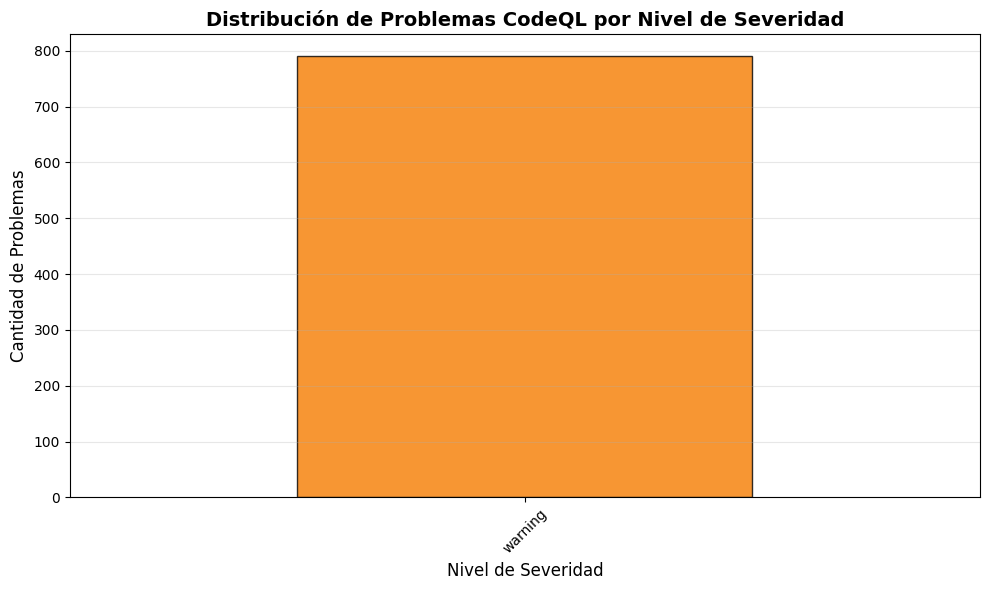

In [16]:
# Gráfico: Distribución por severidad
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = df_codeql['level'].value_counts(
    ).sort_index(ascending=False)

    # Colores según severidad
    colores = {'error': '#d32f2f', 'warning': '#f57c00', 'note': '#7cb342'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Problemas CodeQL por Nivel de Severidad',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad', fontsize=12)
    ax.set_ylabel('Cantidad de Problemas', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

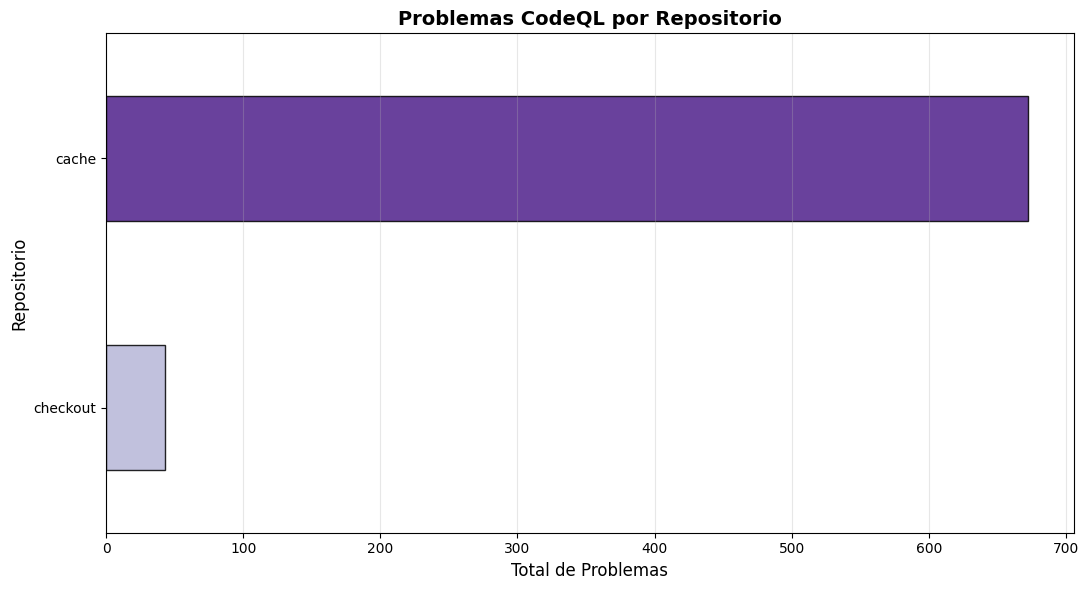

✅ Datos por repositorio exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-repo.json


In [158]:
# Gráfico: Problemas por repositorio (CodeQL)
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo_series = df_codeql['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Purples(np.linspace(0.4, 0.9, len(issues_por_repo_series)))

    issues_por_repo_series.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85
    )

    ax.set_title('Problemas CodeQL por Repositorio', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Problemas', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    df_repo_export = df_codeql['repo'].value_counts().reset_index()
    df_repo_export.columns = ['repo', 'count']

    output_repo_path = data_results / "codeql-analisis" / "estadisticas-repo.json"
    df_repo_export.to_json(output_repo_path, orient='records', indent=4)
    print(f"✅ Datos por repositorio exportados a: {output_repo_path}")

else:
    print("❌ No hay datos disponibles para graficar ni exportar")

In [160]:
# Top 5 reglas más comunes
if len(df_codeql) > 0:
    top_rules = df_codeql['rule_id'].value_counts().head(5)

    print("\n🎯 Top 5 Reglas de Seguridad Más Frecuentes:")
    print("=" * 70)
    for idx, (rule, count) in enumerate(top_rules.items(), 1):
        porcentaje = (count / len(df_codeql)) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje:5.1f}%)")

    # --- NUEVO: EXPORTACIÓN PARA EL DASHBOARD HTML (JSON) ---
    df_rules_export = top_rules.reset_index()
    df_rules_export.columns = ['rule_id', 'count']

    output_rules_path = data_results / "codeql-analisis" / "estadisticas-reglas.json"
    df_rules_export.to_json(output_rules_path, orient='records', indent=4)
    print(f"\n✅ Datos de reglas exportados a: {output_rules_path}")

else:
    print("❌ No hay datos disponibles")


🎯 Top 5 Reglas de Seguridad Más Frecuentes:
 1. js/useless-expression                    256 ( 35.8%)
 2. js/useless-assignment-to-local           159 ( 22.2%)
 3. js/trivial-conditional                    99 ( 13.8%)
 4. js/unneeded-defensive-code                78 ( 10.9%)
 5. js/whitespace-contradicts-precedence      24 (  3.4%)

✅ Datos de reglas exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-reglas.json


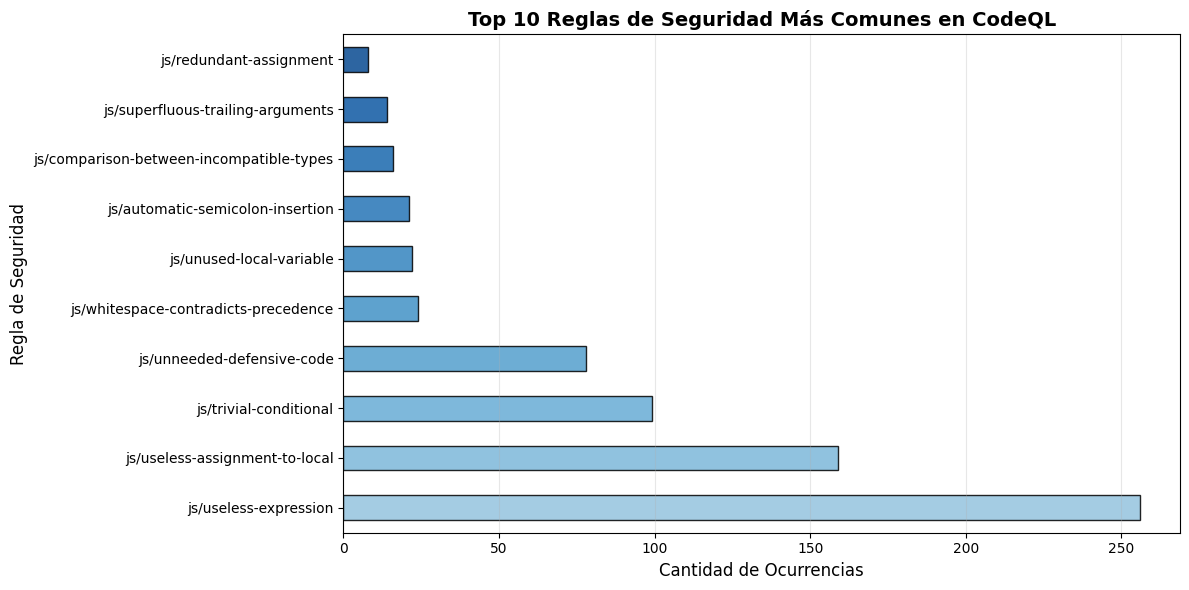

In [161]:
# Gráfico: Top 10 reglas más comunes
if len(df_codeql) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_rules = df_codeql['rule_id'].value_counts().head(10)

    # Colores del gradiente (más oscuro = más frecuente)
    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rules)))

    top_rules.plot(kind='barh', ax=ax, color=colores_gradiente,
                   edgecolor='black', alpha=0.85)

    ax.set_title('Top 10 Reglas de Seguridad Más Comunes en CodeQL',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Ocurrencias', fontsize=12)
    ax.set_ylabel('Regla de Seguridad', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

In [162]:
# 5 reglas mas comunes por repositorio
if len(df_codeql) > 0:
    reglas_por_repo = df_codeql.groupby('repo')['rule_id'].value_counts().unstack(fill_value=0)
 
    print("\n📊 Top 5 Reglas de Seguridad Más Comunes por Repositorio:")
    print("=" * 80)
    
    export_data = []

    for repo in reglas_por_repo.index:
        print(f"📁 {repo:30s}")
        print("-" * 80)

        top_rules = reglas_por_repo.loc[repo].sort_values(ascending=False).head(5)
        rules_list = []
        
        for rule, count in top_rules.items():
            if count > 0:
                porcentaje = (count / df_codeql[df_codeql['repo'] == repo].shape[0]) * 100
                print(f"   - {rule:40s} {count:3d} ({porcentaje:5.1f}%)")
                
                rules_list.append({
                    "rule_id": rule, 
                    "count": int(count),
                    "percentage": round(porcentaje, 1)
                })
        print()
        
        if rules_list:
            export_data.append({
                "repo": repo,
                "rules": rules_list
            })
            
    output_repo_rules_path = data_results / "codeql-analisis" / "estadisticas-repo-reglas.json"
    with open(output_repo_rules_path, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=4)
        
    print(f"✅ Datos anidados exportados a: {output_repo_rules_path}")

else:
    print("❌ No hay datos disponibles")


📊 Top 5 Reglas de Seguridad Más Comunes por Repositorio:
📁 cache                         
--------------------------------------------------------------------------------
   - js/useless-expression                    248 ( 36.9%)
   - js/useless-assignment-to-local           148 ( 22.0%)
   - js/trivial-conditional                    96 ( 14.3%)
   - js/unneeded-defensive-code                72 ( 10.7%)
   - js/whitespace-contradicts-precedence      24 (  3.6%)

📁 checkout                      
--------------------------------------------------------------------------------
   - js/useless-assignment-to-local            11 ( 25.6%)
   - js/useless-expression                      8 ( 18.6%)
   - js/unused-local-variable                   6 ( 14.0%)
   - js/unneeded-defensive-code                 6 ( 14.0%)
   - js/trivial-conditional                     3 (  7.0%)

✅ Datos anidados exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-repo-reglas.json


In [164]:
# Top 5 reglas en el repositorio con más problemass
if len(df_codeql) > 0:
    repo_mas_problemas = df_codeql['repo'].value_counts().idxmax()
    problemas_repo_mas_problemas = df_codeql[df_codeql['repo'] == repo_mas_problemas]
    
    total_repo = len(problemas_repo_mas_problemas)
    total_general = len(df_codeql)
    porcentaje_total = (total_repo / total_general) * 100

    print(f"\n📌 Repositorio con más problemas: {repo_mas_problemas}")
    print(f"📊 Total de problemas: {total_repo}, un {porcentaje_total:.1f}% del total")
    print("\n🎯 Top 5 Reglas de Seguridad Más Frecuentes en este Repositorio:")
    print("=" * 70)
    
    top_rules_repo = problemas_repo_mas_problemas['rule_id'].value_counts().head(5)
    
    reglas_list = []
    for idx, (rule, count) in enumerate(top_rules_repo.items(), 1):
        porcentaje_regla = (count / total_repo) * 100
        print(f"{idx:2d}. {rule:40s} {count:3d} ({porcentaje_regla:5.1f}%)")
        
        reglas_list.append({
            "rule_id": rule,
            "count": int(count),
            "percentage": round(porcentaje_regla, 1)
        })

    export_peor_repo = {
        "repo_name": repo_mas_problemas,
        "total_issues": int(total_repo),
        "percentage_of_total": round(porcentaje_total, 1),
        "top_rules": reglas_list
    }

    output_peor_repo_path = data_results / "codeql-analisis" / "estadisticas-peor-repo.json"
    with open(output_peor_repo_path, 'w', encoding='utf-8') as f:
        json.dump(export_peor_repo, f, indent=4)
        
    print(f"\n✅ Datos del peor repo exportados a: {output_peor_repo_path}")

else:
    print("❌ No hay datos disponibles")


📌 Repositorio con más problemas: cache
📊 Total de problemas: 672, un 94.0% del total

🎯 Top 5 Reglas de Seguridad Más Frecuentes en este Repositorio:
 1. js/useless-expression                    248 ( 36.9%)
 2. js/useless-assignment-to-local           148 ( 22.0%)
 3. js/trivial-conditional                    96 ( 14.3%)
 4. js/unneeded-defensive-code                72 ( 10.7%)
 5. js/whitespace-contradicts-precedence      24 (  3.6%)

✅ Datos del peor repo exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-peor-repo.json


In [165]:
# Top 3 archivos con más vulnerabilidades por repositorio
if len(df_codeql) > 0:
    print("\n📂 Top 3 Archivos con Más Vulnerabilidades por Repositorio:")
    print("=" * 80)
    
    export_archivos = []
    
    for repo in df_codeql['repo'].unique():
        print(f"📁 {repo:30s}")
        print("-" * 80)

        repo_data = df_codeql[df_codeql['repo'] == repo]
        repo_total_issues = repo_data.shape[0]
        
        top_files = repo_data['file'].value_counts().head(3)
        archivos_list = []
        
        for idx, (file, count) in enumerate(top_files.items(), 1):
            porcentaje = (count / repo_total_issues) * 100
            print(f"   - {file:50s} {count:3d} ({porcentaje:5.1f}%)")
            
            archivos_list.append({
                "file_path": file,
                "count": int(count),
                "percentage": round(porcentaje, 1)
            })
        print()
        
        if archivos_list:
            export_archivos.append({
                "repo": repo,
                "files": archivos_list
            })

    output_archivos_path = data_results / "codeql-analisis" / "estadisticas-repo-archivos.json"
    with open(output_archivos_path, 'w', encoding='utf-8') as f:
        json.dump(export_archivos, f, indent=4)
        
    print(f"✅ Datos de archivos exportados a: {output_archivos_path}")

else:
    print("❌ No hay datos disponibles")


📂 Top 3 Archivos con Más Vulnerabilidades por Repositorio:
📁 cache                         
--------------------------------------------------------------------------------
   - dist/restore/index.js                              168 ( 25.0%)
   - dist/restore-only/index.js                         168 ( 25.0%)
   - dist/save/index.js                                 168 ( 25.0%)

📁 checkout                      
--------------------------------------------------------------------------------
   - dist/index.js                                       38 ( 88.4%)
   - src/git-auth-helper.ts                               2 (  4.7%)
   - src/github-api-helper.ts                             1 (  2.3%)

✅ Datos de archivos exportados a: /workspaces/Proyecto-Ciberseguridad/results/codeql-analisis/estadisticas-repo-archivos.json


# Análisis Grype: Vulnerabilidades en Dependencias

## ¿De dónde vienen los datos?

Grype escanea fuentes de dependencias (package.json, requirements.txt, pom.xml, etc.) y las compara contra bases de datos de vulnerabilidades conocidas (CVE, NVD). Devuelve resultados en JSON con información de cada vulnerabilidad encontrada.

### Mapeo de datos: JSON de Grype -> JSON normalizado

| Dato original (Grype) | Dato normalizado | Significado |
|---|---|---|
| `artifact.name` | `package_name` | Nombre de la librería vulnerable (ej: `django`, `lodash`) |
| `artifact.version` | `current_version` | Versión de la librería actualmente instalada |
| `vulnerability.id` | `vuln_id` | Identificador único: CVE-XXXX-XXXXX o equivalente |
| `metadata.cvss[0].score` | `cvss_score` | Puntuación CVSS 0.0-10.0 (escala de severidad numérica) |
| — | `vuln_severity` | **MAPEO**: CVSS→categoría: critical (≥9.0), high (≥7.0), medium (≥4.0), low (<4.0) |
| `fix.versions[0]` | `fix_version` | Versión con el parche disponible (o "N/A" si no hay) |
| `vulnerability.description` | `message` | Descripción del problema |

### Decisión de diseño

**Se realiza transformación CVSS score -> severidad** para mayor legibilidad, pero **se preservan AMBOS valores**. Esto permite:

- Comparar fácilmente con SLAs ("critical en 24h, high en 72h")
- Mantener precisión para usuarios avanzados (CVSS score exacto)

### Visualizaciones esperadas

- Distribución de vulnerabilidades por severidad CVSS
- Paquetes más vulnerables del proyecto

In [166]:
# Cargar todos los análisis Grype
grype_files = sorted(data_results.glob("*-grype.json"))

print(f"\n📂 Buscando archivos Grype en: {data_results}")
print(f"✓ Archivos encontrados: {len(grype_files)}\n")

# Consolidar en un solo DataFrame
data_grype = []

for archivo in grype_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        contenido = json.load(f)

    repo_name = archivo.stem.replace('-grype', '')
    vulns = contenido.get('vulnerabilities', [])

    for vuln in vulns:
        vuln['repo'] = repo_name
        data_grype.append(vuln)

df_grype = pd.DataFrame(data_grype)

print(f"📊 Total de vulnerabilidades cargadas: {len(df_grype)}")
print(
    f"📋 Repositorios únicos: {df_grype['repo'].nunique() if len(df_grype) > 0 else 0}\n")


📂 Buscando archivos Grype en: /workspaces/Proyecto-Ciberseguridad/results
✓ Archivos encontrados: 2

📊 Total de vulnerabilidades cargadas: 11
📋 Repositorios únicos: 2



In [168]:
# Estadísticas por severidad (con rangos CVSS)
if len(df_grype) > 0:
    stats_severity = df_grype['vuln_severity'].value_counts()

    cvss_ranges = {
        'critical': '9.0 - 10.0',
        'high': '7.0 - 8.9',
        'medium': '4.0 - 6.9',
        'low': '0.0 - 3.9'
    }

    print("🔴 Vulnerabilidades por Nivel de Severidad CVSS:")
    print("=" * 60)
    print(f"{'Severidad':<12} {'Cantidad':<10} {'Rango CVSS':<15} {'%':<8}")
    print("=" * 60)

    export_grype_sev = []

    for severidad in ['critical', 'high', 'medium', 'low']:
        cantidad = int(stats_severity.get(severidad, 0))
        porcentaje = (cantidad / len(df_grype) * 100) if len(df_grype) > 0 else 0
        rango = cvss_ranges.get(severidad, 'N/A')
        emoji = "🔴" if severidad == "critical" else "🟠" if severidad == "high" else "🟡" if severidad == "medium" else "⚪"
        print(f"{emoji} {severidad:<10} {cantidad:<10} {rango:<15} {porcentaje:>6.1f}%")

        export_grype_sev.append({
            "level": severidad,
            "count": cantidad,
            "cvss": rango,
            "percentage": round(porcentaje, 1)
        })

    print("=" * 60)
    print(f"📈 Total general: {len(df_grype)} vulnerabilidades encontradas")

    output_grype_sev_path = data_results / "grype-analisis" /"grype-severidad.json"
    with open(output_grype_sev_path, 'w', encoding='utf-8') as f:
        json.dump(export_grype_sev, f, indent=4)
        
    print(f"\n✅ Datos de severidad Grype exportados a: {output_grype_sev_path}")

else:
    print("❌ No hay datos de Grype disponibles")

🔴 Vulnerabilidades por Nivel de Severidad CVSS:
Severidad    Cantidad   Rango CVSS      %       
🔴 critical   0          9.0 - 10.0         0.0%
🟠 high       0          7.0 - 8.9          0.0%
🟡 medium     0          4.0 - 6.9          0.0%
⚪ low        11         0.0 - 3.9        100.0%
📈 Total general: 11 vulnerabilidades encontradas

✅ Datos de severidad Grype exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-severidad.json


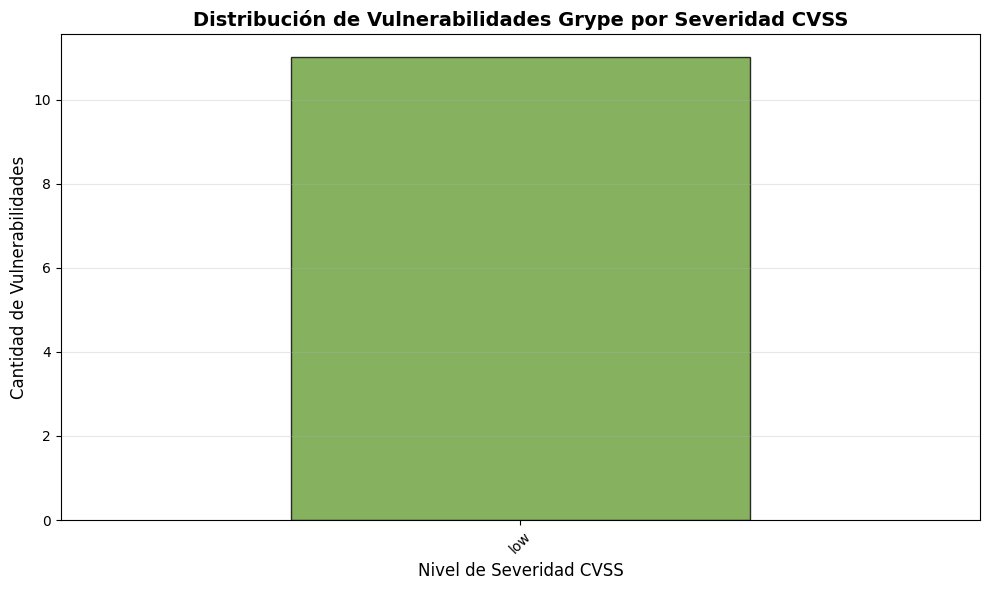

In [169]:
# Gráfico: Distribución por severidad
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Ordenar correctamente: critical > high > medium > low
    severidad_order = ['critical', 'high', 'medium', 'low']
    stats_severity = df_grype['vuln_severity'].value_counts()
    stats_severity = stats_severity.reindex(
        [s for s in severidad_order if s in stats_severity.index])

    # Colores según severidad
    colores = {'critical': '#b71c1c', 'high': '#e64a19',
               'medium': '#fbc02d', 'low': '#689f38'}
    color_list = [colores.get(nivel, '#757575')
                  for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list,
                        edgecolor='black', alpha=0.8)

    ax.set_title('Distribución de Vulnerabilidades Grype por Severidad CVSS',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad CVSS', fontsize=12)
    ax.set_ylabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("❌ No hay datos disponibles para graficar")

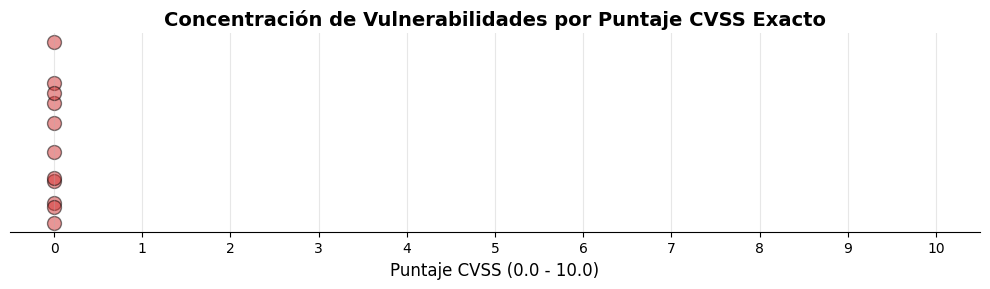

✅ Datos de dispersión CVSS exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-cvss.json


In [170]:
# Gráfico: Dispersión de puntajes CVSS (si están disponibles)
if len(df_grype) > 0 and 'cvss_score' in df_grype.columns:
    fig, ax = plt.subplots(figsize=(10, 3))

    df_cvss = df_grype[df_grype['cvss_score'].apply(lambda x: isinstance(x, (int, float)))].copy()

    if not df_cvss.empty:
        df_cvss['cvss_score'] = pd.to_numeric(df_cvss['cvss_score'], errors='coerce')

        x_vals = df_cvss['cvss_score']
        y_vals = np.ones(len(x_vals)) + np.random.normal(0, 0.05, len(x_vals))

        ax.scatter(x_vals, y_vals, color='#d32f2f', alpha=0.5, edgecolor='black', s=100)

        ax.set_title('Concentración de Vulnerabilidades por Puntaje CVSS Exacto', fontsize=14, fontweight='bold')
        ax.set_xlabel('Puntaje CVSS (0.0 - 10.0)', fontsize=12)
        
        ax.set_xlim(-0.5, 10.5)
        ax.set_xticks(range(11))
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()
        df_cvss_clean = df_cvss.dropna(subset=['cvss_score'])
        
        export_cvss = df_cvss_clean[['package_name', 'cvss_score', 'vuln_severity']].to_dict(orient='records')
        
        output_grype_cvss_path = data_results / "grype-analisis" / "grype-cvss.json"
        with open(output_grype_cvss_path, 'w', encoding='utf-8') as f:
            json.dump(export_cvss, f, indent=4)
            
        print(f"✅ Datos de dispersión CVSS exportados a: {output_grype_cvss_path}")

    else:
        print("❌ No hay puntajes CVSS válidos para graficar ni exportar")
else:
    print("❌ No hay datos de CVSS disponibles")

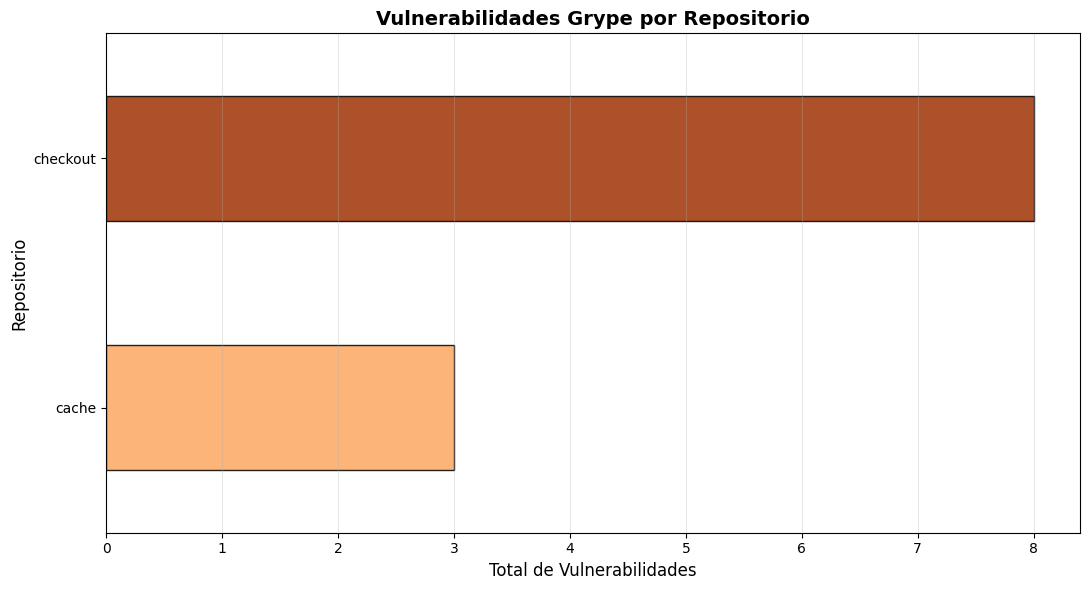

✅ Datos de Grype por repositorio exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-repo.json


In [171]:
# Gráfico: Vulnerabilidades por repositorio (Grype)
if len(df_grype) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    vulns_por_repo = df_grype['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Oranges(np.linspace(0.4, 0.9, len(vulns_por_repo)))

    vulns_por_repo.plot(kind='barh', ax=ax,
                        color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Vulnerabilidades Grype por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Vulnerabilidades', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    df_grype_repo_export = df_grype['repo'].value_counts().reset_index()
    df_grype_repo_export.columns = ['repo', 'count']

    output_grype_repo_path = data_results / "grype-analisis" / "grype-repo.json"
    df_grype_repo_export.to_json(output_grype_repo_path, orient='records', indent=4)
    print(f"✅ Datos de Grype por repositorio exportados a: {output_grype_repo_path}")

else:
    print("❌ No hay datos disponibles para graficar")

In [26]:
# Top 5 paquetes más vulnerables
if len(df_grype) > 0:
    # Agrupar por paquete y mostrar info relevante
    top_packages = df_grype['package_name'].value_counts().head(10)

    print("\n📦 Top 10 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = top_packages[pkg_name]
        version = pkg_data.get('current_version', 'N/A')
        fix = pkg_data.get('fix_version', 'N/A')
        fix_status = "✓ Sí" if fix != 'N/A' else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {str(version):<15} {fix_status:<8}")

else:
    print("❌ No hay datos disponibles")


📦 Top 10 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
undici                         26         5.29.0          ✗ No    
fast-xml-parser                15         5.5.6           ✗ No    
minimatch                      15         3.1.2           ✗ No    
brace-expansion                6          1.1.12          ✗ No    
uuid                           5          3.4.0           ✗ No    
js-yaml                        2          3.13.1          ✗ No    
lodash                         2          4.17.23         ✗ No    
sync-ghes-actions              1          1.0.0           ✗ No    
tar                            1          7.5.10          ✗ No    


In [172]:
# Top 3 paquetes más vulnerables
if len(df_grype) > 0:
    top_packages = df_grype['package_name'].value_counts().head(3)

    print("\n📦 Top 3 Paquetes con Más Vulnerabilidades:")
    print("=" * 80)
    print(f"{'Paquete':<30} {'Vulns':<10} {'Vers. Actual':<15} {'Fix?':<8}")
    print("=" * 80)

    export_top_pkgs = []

    for pkg_name in top_packages.index:
        pkg_data = df_grype[df_grype['package_name'] == pkg_name].iloc[0]
        cantidad = int(top_packages[pkg_name])
        version = str(pkg_data.get('current_version', 'N/A'))
        fix = str(pkg_data.get('fix_version', 'N/A'))
        has_fix = fix != 'N/A'
        fix_status = "✓ Sí" if has_fix else "✗ No"

        print(f"{pkg_name:<30} {cantidad:<10} {version:<15} {fix_status:<8}")

        export_top_pkgs.append({
            "package_name": pkg_name,
            "count": cantidad,
            "current_version": version,
            "has_fix": has_fix,
            "fix_version": fix
        })

    print("=" * 80)

    output_grype_pkgs_path = data_results / "grype-analisis" / "grype-top-paquetes.json"
    with open(output_grype_pkgs_path, 'w', encoding='utf-8') as f:
        json.dump(export_top_pkgs, f, indent=4)
        
    print(f"✅ Datos del Top 3 de paquetes exportados a: {output_grype_pkgs_path}")

else:
    print("❌ No hay datos disponibles")


📦 Top 3 Paquetes con Más Vulnerabilidades:
Paquete                        Vulns      Vers. Actual    Fix?    
undici                         5          5.29.0          ✗ No    
uuid                           3          3.4.0           ✗ No    
fast-xml-parser                2          5.5.6           ✗ No    
✅ Datos del Top 3 de paquetes exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/grype-top-paquetes.json


In [173]:
# Repositorio con mas problemas en total y con menos, contando grype y codeql juntos.
if len(df_codeql) > 0 and len(df_grype) > 0:
    total_problemas = pd.concat([
        df_codeql.groupby('repo').size().rename('codeql_count'),
        df_grype.groupby('repo').size().rename('grype_count')
    ], axis=1).fillna(0)

    total_problemas['total'] = total_problemas['codeql_count'] + total_problemas['grype_count']

    repo_mas_problemas = total_problemas['total'].idxmax()
    repo_menos_problemas = total_problemas[total_problemas['total'] > 0]['total'].idxmin()

    print(f"\n📌 Repositorio con más problemas (CodeQL + Grype): {repo_mas_problemas} ({int(total_problemas.loc[repo_mas_problemas, 'total'])} problemas)")
    print(f"📌 Repositorio con menos problemas (CodeQL + Grype): {repo_menos_problemas} ({int(total_problemas.loc[repo_menos_problemas, 'total'])} problemas)")
    
    export_global = {
        "max": {
            "repo": repo_mas_problemas,
            "total": int(total_problemas.loc[repo_mas_problemas, 'total']),
            "codeql": int(total_problemas.loc[repo_mas_problemas, 'codeql_count']),
            "grype": int(total_problemas.loc[repo_mas_problemas, 'grype_count'])
        },
        "min": {
            "repo": repo_menos_problemas,
            "total": int(total_problemas.loc[repo_menos_problemas, 'total']),
            "codeql": int(total_problemas.loc[repo_menos_problemas, 'codeql_count']),
            "grype": int(total_problemas.loc[repo_menos_problemas, 'grype_count'])
        }
    }
    
    output_global_path = data_results / "grype-analisis" / "resumen-global.json"
    with open(output_global_path, 'w', encoding='utf-8') as f:
        json.dump(export_global, f, indent=4)
        
    print(f"✅ Datos del resumen global exportados a: {output_global_path}")

else:
    print("❌ No hay datos suficientes para determinar repositorios con más/menos problemas")


📌 Repositorio con más problemas (CodeQL + Grype): cache (675 problemas)
📌 Repositorio con menos problemas (CodeQL + Grype): checkout (51 problemas)
✅ Datos del resumen global exportados a: /workspaces/Proyecto-Ciberseguridad/results/grype-analisis/resumen-global.json


## Conclusiones

### Dos perspectivas complementarias

Como habrás observado, **CodeQL y Grype detectan problemas completamente diferentes**:

| Aspecto | CodeQL (SAST) | Grype (SCA) |
|--------|---|---|
| **¿Qué analiza?** | Nuestro propio código fuente | Las librerías que usamos |
| **Severidad** | `error`, `warning`, `note` | CVSS score -> critical, high, medium, low |
| **Acción típica** | Refactorizar código, revisar patrones | Actualizar versión de librería |
| **Remediación** | Manual (requiere fix de código) | Automática (cambiar versión) |

### Cómo interpretarlos

- **CodeQL errors**: Son críticos y pueden permitir ataques. Requieren revisión y fix de código
- **Grype critical**: Vulnerabilidades públicamente conocidas. Actualizar la librería es urgente
- **Ambas**: Son parte de una estrategia integral de seguridad. Usa ambas para máxima cobertura

### Próximos pasos

1. **Para CodeQL errors**: Revisa el análisis detallado en `generacion_codeql.ipynb`
2. **Para Grype critical**: Revisa el análisis detallado en `generacion_grype.ipynb`
3. **Para SBOMs**: Consulta `generacion_sbom.ipynb` para inventario de dependencias